# Fase 1 - Ingenieria de Datos y EDA (Spark SQL)

Limpieza de campos sucios (altura, peso, valor de transferencia), tratamiento de nulos y analisis de correlacion, usando Spark DataFrame API / Spark SQL.

In [1]:
import os
os.environ.setdefault('JAVA_HOME', '/opt/homebrew/opt/openjdk@17')

from pyspark.sql import SparkSession
from pyspark.sql import functions as F
from pyspark.sql.types import DoubleType

spark = SparkSession.builder \
    .appName('ScoutingEDA') \
    .master('local[*]') \
    .config('spark.sql.shuffle.partitions', '8') \
    .getOrCreate()
spark.sparkContext.setLogLevel('WARN')

df = spark.read.csv('../data/raw/merged_players.csv', header=True, inferSchema=True)
print((df.count(), len(df.columns)))

Using Spark's default log4j profile: org/apache/spark/log4j2-defaults.properties
26/07/15 15:54:29 WARN Utils: Your hostname, MacBook-de-Rodrigo.local, resolves to a loopback address: 127.0.0.1; using 192.168.1.123 instead (on interface en0)
26/07/15 15:54:29 WARN Utils: Set SPARK_LOCAL_IP if you need to bind to another address


Using Spark's default log4j profile: org/apache/spark/log4j2-defaults.properties
Setting default log level to "WARN".
To adjust logging level use sc.setLogLevel(newLevel). For SparkR, use setLogLevel(newLevel).


26/07/15 15:54:30 WARN NativeCodeLoader: Unable to load native-hadoop library for your platform... using builtin-java classes where applicable


(91672, 88)


In [2]:
df.printSchema()

root
 |-- _c0: integer (nullable = true)
 |-- UID: integer (nullable = true)
 |-- Name: string (nullable = true)
 |-- Rec: string (nullable = true)
 |-- DOB: string (nullable = true)
 |-- Inf: string (nullable = true)
 |-- Club: string (nullable = true)
 |-- Based: string (nullable = true)
 |-- Nat: string (nullable = true)
 |-- Height: string (nullable = true)
 |-- Weight: string (nullable = true)
 |-- Age: integer (nullable = true)
 |-- Position: string (nullable = true)
 |-- Transfer Value: string (nullable = true)
 |-- Media Description: string (nullable = true)
 |-- Rc Injury: string (nullable = true)
 |-- Preferred Foot: string (nullable = true)
 |-- Left Foot: string (nullable = true)
 |-- Right Foot: string (nullable = true)
 |-- Caps: integer (nullable = true)
 |-- AT Apps: string (nullable = true)
 |-- AT Gls: string (nullable = true)
 |-- AT Lge Apps: string (nullable = true)
 |-- AT Lge Gls: string (nullable = true)
 |-- Team: string (nullable = true)
 |-- Yth Apps: string 

## Limpieza de campos sucios

- `Height` (`5'9"`) -> centimetros.
- `Weight` (`65 kg`) -> numero.
- `Transfer Value`: es un **rango** con sufijos K/M (`'250K$ - 2.5M$'`) y puede venir como `'Not for Sale'` o valor unico (`'0$'`). Se parsea a limite inferior, superior y un punto estimado (promedio).

In [3]:
# Altura: pies'pulgadas" -> cm
df = df.withColumn(
    'Height_cm',
    F.round(
        (F.regexp_extract('Height', r"(\d+)'", 1).cast('double') * 12 +
         F.regexp_extract('Height', r"'(\d+)\"", 1).cast('double')) * 2.54,
        1
    )
)

# Peso: 'NN kg' -> numero
df = df.withColumn('Weight_kg', F.regexp_extract('Weight', r'(\d+)\s*kg', 1).cast('double'))

df.select('Height', 'Height_cm', 'Weight', 'Weight_kg').show(5)

+------+---------+------+---------+
|Height|Height_cm|Weight|Weight_kg|
+------+---------+------+---------+
| 5'9""|    175.3| 65 kg|     65.0|
| 5'4""|    162.6| 56 kg|     56.0|
| 6'2""|    188.0| 77 kg|     77.0|
| 6'1""|    185.4| 74 kg|     74.0|
| 6'0""|    182.9| 72 kg|     72.0|
+------+---------+------+---------+
only showing top 5 rows


In [4]:
def parse_money_to_number(col_expr):
    """Convierte '250K$' o '2.5M$' o '0$' a double."""
    number = F.regexp_extract(col_expr, r'([\d.]+)', 1).cast('double')
    suffix = F.regexp_extract(col_expr, r'([KM])\$', 1)
    multiplier = F.when(suffix == 'K', 1e3).when(suffix == 'M', 1e6).otherwise(1.0)
    return number * multiplier

is_range = F.col('Transfer Value').contains(' - ')
is_not_for_sale = F.col('Transfer Value') == 'Not for Sale'

low_part = F.when(is_range, F.split('Transfer Value', ' - ').getItem(0)).otherwise(F.col('Transfer Value'))
high_part = F.when(is_range, F.split('Transfer Value', ' - ').getItem(1)).otherwise(F.col('Transfer Value'))

df = df.withColumn('Transfer_Value_Low', F.when(is_not_for_sale, None).otherwise(parse_money_to_number(low_part)))
df = df.withColumn('Transfer_Value_High', F.when(is_not_for_sale, None).otherwise(parse_money_to_number(high_part)))
df = df.withColumn(
    'Transfer_Value_num',
    F.when(is_not_for_sale, None).otherwise((F.col('Transfer_Value_Low') + F.col('Transfer_Value_High')) / 2)
)

df.select('Transfer Value', 'Transfer_Value_Low', 'Transfer_Value_High', 'Transfer_Value_num').show(15, truncate=False)

+--------------+------------------+-------------------+------------------+
|Transfer Value|Transfer_Value_Low|Transfer_Value_High|Transfer_Value_num|
+--------------+------------------+-------------------+------------------+
|0$            |0.0               |0.0                |0.0               |
|0$            |0.0               |0.0                |0.0               |
|0$            |0.0               |0.0                |0.0               |
|0$            |0.0               |0.0                |0.0               |
|0$            |0.0               |0.0                |0.0               |
|0$            |0.0               |0.0                |0.0               |
|0$            |0.0               |0.0                |0.0               |
|0$            |0.0               |0.0                |0.0               |
|0$            |0.0               |0.0                |0.0               |
|0$            |0.0               |0.0                |0.0               |
|0$            |0.0      

## Tratamiento de nulos y atipicos

In [5]:
# 'Rec' (recomendacion del scout) usa '- - -' como marcador de nulo y es categorica, no numerica
df = df.withColumn('Rec', F.when(F.col('Rec').cast('string') == '- - -', None).otherwise(F.col('Rec')))

# Estas si son conteos de carrera/seleccion: '-' como marcador de nulo, numericas.
# inferSchema las detecto como numericas, por lo que comparamos como string antes de castear
# (en modo ANSI, comparar una columna numerica contra '-' directamente lanza un error de cast).
dash_null_cols = ['Caps', 'AT Apps', 'AT Gls', 'AT Lge Apps', 'AT Lge Gls', 'Yth Apps', 'Yth Gls']
for c in dash_null_cols:
    df = df.withColumn(c, F.when(F.col(c).cast('string') == '-', None).otherwise(F.col(c).cast('double')))

null_check_cols = ['Rec'] + dash_null_cols + ['Transfer_Value_num', 'Height_cm', 'Weight_kg']
df.select([F.count(F.when(F.col(c).isNull(), c)).alias(c) for c in null_check_cols]).show()

+-----+----+-------+------+-----------+----------+--------+-------+------------------+---------+---------+
|  Rec|Caps|AT Apps|AT Gls|AT Lge Apps|AT Lge Gls|Yth Apps|Yth Gls|Transfer_Value_num|Height_cm|Weight_kg|
+-----+----+-------+------+-----------+----------+--------+-------+------------------+---------+---------+
|91672|   0|  25820| 43274|      26102|     43392|   84203|  88770|              2051|        0|        0|
+-----+----+-------+------+-----------+----------+--------+-------+------------------+---------+---------+



In [6]:
# 'Not for Sale' y jugadores sin Transfer Value valido: se documentan y se excluyen del modelado de regresion
n_not_for_sale = df.filter(F.col('Transfer Value') == 'Not for Sale').count()
n_null_value = df.filter(F.col('Transfer_Value_num').isNull()).count()
print(f"Not for Sale: {n_not_for_sale}")
print(f"Transfer_Value_num nulo: {n_null_value}")

Not for Sale: 2051
Transfer_Value_num nulo: 2051


### Deteccion de atipicos (IQR)

Se aplica el criterio de rango intercuartilico (`Q1 - 1.5*IQR`, `Q3 + 1.5*IQR`) sobre las variables numericas
mas sensibles a errores de parsing o valores extremos de negocio: `Height_cm`, `Weight_kg`, `Age` y
`Transfer_Value_num`.

In [7]:
quantile_cols = ['Height_cm', 'Weight_kg', 'Age', 'Transfer_Value_num']

for c in quantile_cols:
    q1, q3 = df.approxQuantile(c, [0.25, 0.75], 0.01)
    iqr = q3 - q1
    lower, upper = q1 - 1.5 * iqr, q3 + 1.5 * iqr
    n_out = df.filter((F.col(c) < lower) | (F.col(c) > upper)).count()
    n_total = df.filter(F.col(c).isNotNull()).count()
    print(f"{c}: Q1={q1:.1f} Q3={q3:.1f} IQR={iqr:.1f} -> rango valido=({lower:.1f}, {upper:.1f}), "
          f"atipicos={n_out} ({n_out / n_total * 100:.1f}% de {n_total})")

df.select(
    F.min('Height_cm').alias('Height_cm_min'), F.max('Height_cm').alias('Height_cm_max'),
    F.min('Weight_kg').alias('Weight_kg_min'), F.max('Weight_kg').alias('Weight_kg_max'),
).show()

Height_cm: Q1=175.3 Q3=185.4 IQR=10.1 -> rango valido=(160.2, 200.6), atipicos=584 (0.6% de 91672)


Weight_kg: Q1=68.0 Q3=78.0 IQR=10.0 -> rango valido=(53.0, 93.0), atipicos=440 (0.5% de 91672)


Age: Q1=19.0 Q3=28.0 IQR=9.0 -> rango valido=(5.5, 41.5), atipicos=103 (0.1% de 91672)


Transfer_Value_num: Q1=0.0 Q3=275000.0 IQR=275000.0 -> rango valido=(-412500.0, 687500.0), atipicos=14010 (15.6% de 89621)


+-------------+-------------+-------------+-------------+
|Height_cm_min|Height_cm_max|Weight_kg_min|Weight_kg_max|
+-------------+-------------+-------------+-------------+
|        149.9|        208.3|         55.0|        111.0|
+-------------+-------------+-------------+-------------+



**Decision y justificacion:**

- `Transfer_Value_num`: el criterio IQR marca como "atipicos" a las superestrellas (Mbappe, Haaland, etc.).
  **No se eliminan ni se capan** — son precisamente el segmento que el consorcio quiere modelar (superestrellas
  inalcanzables vs. sus "clones" de bajo costo, ver Fase 2). Quitarlos destruiria el objetivo de negocio.
- `Height_cm` / `Weight_kg`: a diferencia del valor de transferencia, no existe una razon futbolistica para que
  un jugador profesional mida <140cm o pese >110kg — un valor asi es casi con certeza un error de parsing o de
  captura de datos, no una senal real. Se valida contra un rango fisiologicamente plausible y se marca como
  nulo (no se inventa un valor de reemplazo) lo que caiga fuera, para no contaminar el modelo con ruido de
  captura.
- `Age`: rango de jugadores profesionales (16-45 aprox.) ya es consistente con el IQR, no se interviene.

In [8]:
# Rango fisiologicamente plausible para futbolistas profesionales
n_height_before = df.filter(F.col('Height_cm').isNotNull()).count()
n_weight_before = df.filter(F.col('Weight_kg').isNotNull()).count()

df = df.withColumn(
    'Height_cm',
    F.when((F.col('Height_cm') < 140) | (F.col('Height_cm') > 210), None).otherwise(F.col('Height_cm'))
)
df = df.withColumn(
    'Weight_kg',
    F.when((F.col('Weight_kg') < 50) | (F.col('Weight_kg') > 110), None).otherwise(F.col('Weight_kg'))
)

n_height_after = df.filter(F.col('Height_cm').isNotNull()).count()
n_weight_after = df.filter(F.col('Weight_kg').isNotNull()).count()
print(f"Height_cm: {n_height_before - n_height_after} valores marcados como nulos por estar fuera de rango")
print(f"Weight_kg: {n_weight_before - n_weight_after} valores marcados como nulos por estar fuera de rango")

Height_cm: 0 valores marcados como nulos por estar fuera de rango
Weight_kg: 1 valores marcados como nulos por estar fuera de rango


## Analisis de correlacion

Atributos tecnicos/fisicos/mentales (FM attributes) vs. `Transfer_Value_num`.

In [9]:
# 'Nat.1' NO es un duplicado de nacionalidad ni de "habilidad natural": segun el diccionario de datos
# (Diccionario_Datos_FM23.pdf) es el atributo 'Natural Fitness' (forma fisica natural / nivel de
# recuperacion entre partidos y tras lesiones), un atributo distinto de 'Nat' (nacionalidad). Se
# renombra porque el punto en el nombre confunde a APIs como df.stat.corr (lo interpreta como campo
# anidado).
df = df.withColumnRenamed('Nat.1', 'Forma_Fisica_Natural')

attribute_cols = [
    'Acc','Wor','Vis','Thr','Tec','Tea','Tck','Str','Sta','TRO','Ref','Pun','Pos','Pen','Pas','Pac',
    '1v1','OtB','Forma_Fisica_Natural','Mar','L Th','Lon','Ldr','Kic','Jum','Hea','Han','Fre','Fla','Fir','Fin','Ecc',
    'Dri','Det','Dec','Cro','Cor','Cnt','Cmp','Com','Cmd','Bra','Bal','Ant','Agi','Agg','Aer','Vers',
    'Temp','Spor','Prof','Pres','Loy','Inj Pr','Imp M','Dirt','Amb','Ada','Cons','Cont',
]

correlations = []
for c in attribute_cols:
    corr = df.stat.corr(c, 'Transfer_Value_num')
    correlations.append((c, corr))

corr_df = spark.createDataFrame(correlations, ['atributo', 'correlacion_con_transfer_value'])
corr_df.orderBy(F.desc('correlacion_con_transfer_value')).show(20, truncate=False)

+--------+------------------------------+
|atributo|correlacion_con_transfer_value|
+--------+------------------------------+
|Cmp     |0.17493662042456046           |
|Ant     |0.1618314467896632            |
|Tea     |0.15370188757270214           |
|Bal     |0.1536126423741744            |
|Vis     |0.15234812215706525           |
|Pas     |0.15003935177788635           |
|Cnt     |0.14704945747684628           |
|Wor     |0.14451514327824333           |
|Amb     |0.14379708570698396           |
|Sta     |0.13958628341105386           |
|Tec     |0.1365863550710163            |
|Pac     |0.13114668865362655           |
|Prof    |0.12749144399078902           |
|Pen     |0.1271741737890464            |
|Str     |0.1247867071530421            |
|Bra     |0.12437050232092321           |
|Fir     |0.1231878379084709            |
|Dri     |0.12115665592388873           |
|Agi     |0.11933515906807513           |
|Acc     |0.11222455697822369           |
+--------+------------------------

**Lectura de la tabla:** los atributos con mayor correlacion individual con el valor de transferencia son
mentales/tecnicos (`Cmp` compostura, `Ant` anticipacion, `Tea` juego en equipo, `Bal` balance, `Vis` vision,
`Pas` pase) mas que puramente fisicos (`Acc`, `Str` aparecen mas abajo). Sin embargo, las magnitudes son
modestas (~0.12-0.17): ningun atributo aislado explica el valor de mercado por si solo, lo cual es coherente
con que el valor de un jugador es multidimensional (mezcla posicion, edad, liga, marca personal, etc., no solo
habilidad). Esto motiva usar **todos** los atributos en conjunto (via reduccion de dimensionalidad y, en la
Fase 3, modelos supervisados multivariados) en vez de depender de una sola variable.

## Reduccion de dimensionalidad (PCA)

Los ~55 atributos tecnicos/fisicos/mentales estan correlacionados entre si (ej. jugadores tecnicos suelen ser
tambien buenos pasadores y visionarios). Se aplica PCA sobre estos atributos (estandarizados) para cuantificar
cuanta informacion redundante hay y cuantas dimensiones "reales" explican la mayor parte de la varianza.

26/07/15 15:54:54 WARN SparkStringUtils: Truncated the string representation of a plan since it was too large. This behavior can be adjusted by setting 'spark.sql.debug.maxToStringFields'.


26/07/15 15:54:56 WARN InstanceBuilder: Failed to load implementation from:dev.ludovic.netlib.blas.JNIBLAS


26/07/15 15:54:56 WARN InstanceBuilder: Failed to load implementation from:dev.ludovic.netlib.lapack.JNILAPACK


PC1: varianza=0.251  acumulada=0.251
PC2: varianza=0.126  acumulada=0.377
PC3: varianza=0.076  acumulada=0.453
PC4: varianza=0.036  acumulada=0.488
PC5: varianza=0.030  acumulada=0.519
PC6: varianza=0.029  acumulada=0.548
PC7: varianza=0.023  acumulada=0.570
PC8: varianza=0.021  acumulada=0.592
PC9: varianza=0.018  acumulada=0.610
PC10: varianza=0.017  acumulada=0.627
PC11: varianza=0.017  acumulada=0.644
PC12: varianza=0.016  acumulada=0.660
PC13: varianza=0.016  acumulada=0.675
PC14: varianza=0.015  acumulada=0.690
PC15: varianza=0.014  acumulada=0.705


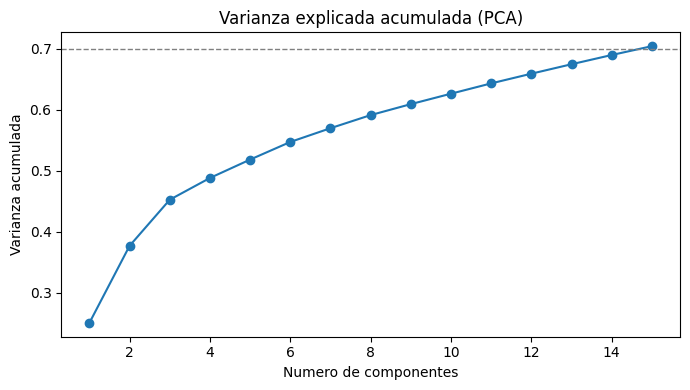

In [10]:
from pyspark.ml.feature import VectorAssembler, StandardScaler, PCA
from pyspark.ml import Pipeline
import matplotlib.pyplot as plt

df_pca_input = df.na.drop(subset=attribute_cols)

assembler_pca = VectorAssembler(inputCols=attribute_cols, outputCol='features_raw')
scaler_pca = StandardScaler(inputCol='features_raw', outputCol='features_scaled', withMean=True, withStd=True)
pca = PCA(k=15, inputCol='features_scaled', outputCol='pca_features')

pipeline_pca = Pipeline(stages=[assembler_pca, scaler_pca, pca])
pca_model = pipeline_pca.fit(df_pca_input)

explained_variance = pca_model.stages[-1].explainedVariance.toArray()
cumulative = explained_variance.cumsum()
for i, (var, cum) in enumerate(zip(explained_variance, cumulative), start=1):
    print(f"PC{i}: varianza={var:.3f}  acumulada={cum:.3f}")

plt.figure(figsize=(7, 4))
plt.plot(range(1, len(cumulative) + 1), cumulative, marker='o')
plt.axhline(0.7, color='gray', linestyle='--', linewidth=1)
plt.title('Varianza explicada acumulada (PCA)')
plt.xlabel('Numero de componentes')
plt.ylabel('Varianza acumulada')
plt.tight_layout()
plt.savefig('../reports/figures/pca_varianza_explicada.png', dpi=120)
plt.show()

**Interpretacion:** el primer componente (`PC1`) por si solo explica ~25% de la varianza y los dos primeros
(`PC1`+`PC2`) ~38% — evidencia de que hay una redundancia fuerte entre los atributos (varios miden, en el
fondo, un mismo "nivel general" del jugador). Sin embargo, se necesitan **15 componentes para llegar a ~70%**
de la varianza acumulada: no hay una reduccion drastica posible sin perder informacion relevante, es decir la
habilidad de un jugador es genuinamente multidimensional (tecnica, fisico y mentalidad aportan cada uno
varianza propia). Esto confirma la decision, en las Fases 2 y 3, de trabajar con el conjunto completo de
atributos (via `VectorAssembler` + `StandardScaler`) en vez de reducir a 2-3 componentes antes de modelar —
la reduccion de dimensionalidad aqui sirve para diagnostico y visualizacion (ver PCA 2D de los clusters en la
Fase 2), no para reemplazar los atributos originales como input de los modelos.

## Exportar dataset limpio

In [11]:
df.write.mode('overwrite').parquet('../data/processed/players_clean.parquet')
print('Guardado en data/processed/players_clean.parquet')

26/07/15 15:54:57 WARN CSVHeaderChecker: CSV header does not conform to the schema.
 Header: , UID, Name, Rec, DOB, Inf, Club, Based, Nat, Height, Weight, Age, Position, Transfer Value, Media Description, Rc Injury, Preferred Foot, Left Foot, Right Foot, Caps, AT Apps, AT Gls, AT Lge Apps, AT Lge Gls, Team, Yth Apps, Yth Gls, Acc, Wor, Vis, Thr, Tec, Tea, Tck, Str, Sta, TRO, Ref, Pun, Pos, Pen, Pas, Pac, 1v1, OtB, Nat.1, Mar, L Th, Lon, Ldr, Kic, Jum, Hea, Han, Fre, Fla, Fir, Fin, Ecc, Dri, Det, Dec, Cro, Cor, Cnt, Cmp, Com, Cmd, Bra, Bal, Ant, Agi, Agg, Aer, Vers, Temp, Spor, Prof, Pres, Loy, Inj Pr, Imp M, Dirt, Amb, Ada, Cons, Cont, Media Handling
 Schema: _c0, UID, Name, Rec, DOB, Inf, Club, Based, Nat, Height, Weight, Age, Position, Transfer Value, Media Description, Rc Injury, Preferred Foot, Left Foot, Right Foot, Caps, AT Apps, AT Gls, AT Lge Apps, AT Lge Gls, Team, Yth Apps, Yth Gls, Acc, Wor, Vis, Thr, Tec, Tea, Tck, Str, Sta, TRO, Ref, Pun, Pos, Pen, Pas, Pac, 1v1, OtB, Nat.

Guardado en data/processed/players_clean.parquet
